In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/kaggle/input/combine-csv/Combined .csv')

In [3]:
df.head()

,Sr. No.,News Items,Label
0,1,ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...,FAKE
1,2,مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔,FAKE
2,3,فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔,FAKE
3,4,جعلی خبریں: پاپ اسٹار حدیقہ کیانی نے جعلی منشی...,FAKE
4,5,صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...,FAKE


In [4]:
# Ab specific labels ko 'TRUE' ya 'FAKE' main convert karain
df['Label'] = df['Label'].replace({
    'TRUE': 'TRUE',
    'TRUE ': 'TRUE',
    'FAKE': 'FAKE',
    'FAKE ': 'FAKE',
})

In [5]:
df.drop(columns=['Sr. No.'],inplace=True)

In [6]:
 #Filter out rows where the column has value 'label'
df = df[df['Label'] != 'Label']
print(df)

                                              News Items Label
0      ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...  FAKE
1              مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔  FAKE
2         فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔  FAKE
3      جعلی خبریں: پاپ اسٹار حدیقہ کیانی نے جعلی منشی...  FAKE
4      صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...  FAKE
...                                                  ...   ...
10079  بے روزگاری الاؤنس، کیش بیک اسکیمیں - کانگریس ن...  TRUE
10080  چدمبرم نے بجٹ پر تنقید کی، حکومت کا کہنا ہے کہ...  TRUE
10081  نتیش نے بہار میں 16,443 کلومیٹر طویل انسانی زن...  TRUE
10082  بھارت کے نوجوان معروف سوشل میڈیا اسٹار اور کام...  TRUE
10083  کراچی: ’’صحیح وقت پر شادی کر لی ہوتی تو دونوں ...  TRUE

[10083 rows x 2 columns]


In [7]:
df['Label']=df['Label'].map({'FAKE':0,'TRUE':1})

In [8]:
import torch
print("GPU Available:", torch.cuda.is_available())  
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


GPU Available: True
Device: cuda


In [9]:
#text normalization :sentence segmentation to remove full stop ,question marks etc
import re

def manual_normalize_text(text):
    # Remove diacritics (zabar, zer, pesh)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    # Remove non-Urdu characters (punctuation, digits, special symbols)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply normalization to the 'News Items' column
df['News Items'] = df['News Items'].apply(manual_normalize_text)
print(df.head())

                                          News Items  Label
0  ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...      0
1          مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔      0
2     فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔      0
3  جعلی خبریں پاپ اسٹار حدیقہ کیانی نے جعلی منشیا...      0
4  صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...      0


In [10]:
'''# stop word removal

# Manually define a set of Urdu stopwords (you can expand this list)
urdu_stopwords = set(["تھا","ہیں","ہے","کیا","آپکے", "آپکا", "آپکو", "ہاں", "ہوں", "ہوگا", "ہوگی", "ہوگے", "ت", "و", "کہیں", "وغیرہ",
    "ا", "ان", "انکے", "انکی", "انکو", "انہوں", "انہیں", "اور", "ایسے", "ب", "بہت", "تاکہ", "تھا",
    "تھی", "تھے", "تھیں", "جب", "جبکہ", "جو", "حالانکہ", "خواہ", "خود", "دو", "دی", "دیا", "دیتے",
    "دیکھا", "دیکھو", "دیں", "رہا", "رہی", "رہے", "رہیں", "رہے", "ساتھ", "سب", "سبھی", "سو", "سے",
    "شاید", "صرف", "ضرور", "ضرورت", "ضروری", "طرح", "طرف", "طور", "علاوہ", "عین", "غیر", "لیکن", "مگر",
    "میں", "نہ", "نہیں", "والا", "والوں", "والی", "والیں", "والے", "وغیرہ", "وہ", "وہاں", "وہی", "وہیں",
    "پ", "پر", "پوری", "پھر", "چاہئے", "چاہتے", "چاہیے", "چاہیں", "چونکہ", "چکی", "چکے", "چکیں", "چکے",
    "چنانچہ", "چند", "چکی", "چکے", "کر", "کرتا", "کرتی", "کرتے", "کرتی", "کرتے", "کرنا", "کرنے", "کرنی",
    "کرنے", "کرنی", "کرنے", "کرنیں", "کرنے", "کرنیں", "کرنے", "کرنیں", "کرے", "کریں", "کم", "کس", "کسی",
    "کسے", "کی", "کیسے", "کیونکہ", "کے", "گئی", "گئے", "گئیں", "گئے", "گا", "گائیں", "گرم", "گریبان", "گریبانیں",
    "گی", "گیا", "گیں", "ہر", "ہم", "ہمیں", "ہو", "ہوئی", "ہوئیں", "ہوئے", "ہوئیں", "ہوتا", "ہوتی", "ہوتے",
    "ہوتی", "ہوتے", "ہونا", "ہونگے", "ہونگی", "ہونگے", "ہونی", "ہونیں", "ہونے", "ہونیں", "ہوں", "ہوگا", "ہوگی",
    "ہوگا", "ہوگی", "ہوگے", "ہوگیں", "یا", "یہ", "یہاں", "یہی", "یہیں", "یہے","اب","ابھی","اپنا","اپنے","اپنی",
    "اٹھا","اس","اسے","اسی","اگر","ان","انہوں","انہی","انہیں","انھیں","او","اور","اے","ایسا","ایسے","ایسی","ایک",
    "آ","آپ","آتا","آتے","آتی","آگے","آنا","آنے","آنی","آئے","آئی","آئیں","آیا","با","بڑا","بڑے","بڑی","بعد","بعض",
    "بلکہ","بہت","بھی","بے","پاس","پر","پہلے","پھر","تا","تاکہ","تب","تجھ","تجھے","تک","تم","تمام","تمہارا","تمہارے",
    "تمھارے","تمہاری","تمہیں","تمھیں","تھا","تھے","تھی","تھیں","تو","تیری","تیرے","جا","جاتا","جاتی","جاتے","جاتی","جانے",
    "جانی","جاؤ","جائے","جائیں","جب","جس","جن","جنہوں","جنہیں","جو","جیسا","جیسے","جیسی","جیسوں","چاہیئے","چلا","چاہے","چونکہ",
    "حالاں","حالانکہ","دو","دونوں","دوں","دے","دی","دیا","دیں","دیے","دیتا","دیتے","دیتی","دینا","دینے","دینی","دیئے","ڈالا","ڈالنا",
    "ڈالنے","ڈالنی","ڈالے","ڈالی","ذرا","رکھا","رکھتا","رکھتے","رکھتی","رکھنا","رکھنے","رکھنی","رکھے","رکھی","رہ","رہا","رہتا","رہتے",
    "رہتی","رہنا","رہنے","رہنی","رہو","رہے","رہی","رہیں","زیادہ","سا","سامنے","سب","سکتا","سو","سے","سی","شاید","صرف","طرح","طرف","عین",
    "کا","کبھی","کچھ","کہہ","کر","کرتا","کرتے","کرتی","کرنا","کرنے","کرو","کروں","کرے","کریں","کس","کسے","کسی","کہ","کہا","کہے","کو","کون",
    "کوئی","کے","کی","کیا","کیسے","کیوں","کیونکہ","کیے","کئے","گا","گویا","گے","گی","گیا","گئے","گئی","لا","لاتا","لاتے","لاتی","لانا","لانے","لانی",
    "لایا","لائے","لائی","لگا","لگے","لگی","لگیں","لو","لے","لی","لیا","لیتا","لیتے","لیتی","لیکن","لیں","لیے","لئے","مجھ","مجھے","مگر","میرا",
    "میرے","میری","میں","نا","نہ","نہایت","نہیں","نے","ہاں","ہر","ہم","ہمارا","ہمارے","ہماری","ہو","ہوا","ہوتا","ہوتے","ہوتی","ہوتیں","ہوں",
    "ہونا","ہونگے","ہونے","ہونی","ہوئے","ہوئی","ہوئیں","ہے","ہی","ہیں","و","والا","والوں","والے","والی","وہ","وہاں","وہی","وہیں","یا","یعنی",
    "یہ","یہاں","یہی","یہیں"
    
])

def remove_stopwords(text):
    # Tokenize the text
    tokens = text.split()
    # Remove stopwords from tokens
    filtered_tokens = [word for word in tokens if word not in urdu_stopwords]
    return ' '.join(filtered_tokens)

# Example of applying stop word removal
df['News Items'] = df['News Items'].apply(remove_stopwords)

# Check the result
print(df.head())'''

'# stop word removal\n\n# Manually define a set of Urdu stopwords (you can expand this list)\nurdu_stopwords = set(["تھا","ہیں","ہے","کیا","آپکے", "آپکا", "آپکو", "ہاں", "ہوں", "ہوگا", "ہوگی", "ہوگے", "ت", "و", "کہیں", "وغیرہ",\n    "ا", "ان", "انکے", "انکی", "انکو", "انہوں", "انہیں", "اور", "ایسے", "ب", "بہت", "تاکہ", "تھا",\n    "تھی", "تھے", "تھیں", "جب", "جبکہ", "جو", "حالانکہ", "خواہ", "خود", "دو", "دی", "دیا", "دیتے",\n    "دیکھا", "دیکھو", "دیں", "رہا", "رہی", "رہے", "رہیں", "رہے", "ساتھ", "سب", "سبھی", "سو", "سے",\n    "شاید", "صرف", "ضرور", "ضرورت", "ضروری", "طرح", "طرف", "طور", "علاوہ", "عین", "غیر", "لیکن", "مگر",\n    "میں", "نہ", "نہیں", "والا", "والوں", "والی", "والیں", "والے", "وغیرہ", "وہ", "وہاں", "وہی", "وہیں",\n    "پ", "پر", "پوری", "پھر", "چاہئے", "چاہتے", "چاہیے", "چاہیں", "چونکہ", "چکی", "چکے", "چکیں", "چکے",\n    "چنانچہ", "چند", "چکی", "چکے", "کر", "کرتا", "کرتی", "کرتے", "کرتی", "کرتے", "کرنا", "کرنے", "کرنی",\n    "کرنے", "کرنی", "کرنے", "کرنیں", "کرنے", "کرن

In [11]:
''''# stemming mean converting words into their root words
!pip install simple-urdu-stemmer
from simple_urdu_stemmer import UrduStemmer

# Stemmer initialize karo
stemmer = UrduStemmer()

# Function to apply stemming
def apply_stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

# Apply stemming on 'News Items' column
df['News Items'] = df['News Items'].apply(apply_stemming)

# Check result
print(df.head())'''

"'# stemming mean converting words into their root words\n!pip install simple-urdu-stemmer\nfrom simple_urdu_stemmer import UrduStemmer\n\n# Stemmer initialize karo\nstemmer = UrduStemmer()\n\n# Function to apply stemming\ndef apply_stemming(text):\n    words = text.split()\n    stemmed_words = [stemmer.stem(word) for word in words]\n    return ' '.join(stemmed_words)\n\n# Apply stemming on 'News Items' column\ndf['News Items'] = df['News Items'].apply(apply_stemming)\n\n# Check result\nprint(df.head())"

In [12]:
#Tokenization step:convert text into tokens or words
from transformers import AutoTokenizer
#loading the tokenizer
Tokenizer=AutoTokenizer.from_pretrained('distilbert-base-multilingual-cased')

#convert text into tokens
tokens=Tokenizer(df['News Items'].tolist(),
                 max_length=512,
                 padding=True,
                 truncation=True,
                 return_tensors='pt')
#cheching the tokenized data
print(tokens.keys())


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

dict_keys(['input_ids', 'attention_mask'])


st> ep3: Loading the Bert model****# 

In [13]:
#step3:loading the bert model
from transformers import AutoModelForSequenceClassification
#loading the bert model for ake news detection
model=AutoModelForSequenceClassification.from_pretrained('distilbert-base-multilingual-cased',
                                                         num_labels=2 #for fake and real
                                                         )
 #Dropout ko set karna
model.config.hidden_dropout_prob = 0.3 # Default = 0.1, increase to reduce overfitting
model.config.attention_probs_dropout_prob = 0.3# Attention layer dropout

print("Hidden Dropout:", model.config.hidden_dropout_prob)
print("Attention Dropout:", model.config.attention_probs_dropout_prob)

2025-04-21 07:07:10.487497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745219230.666132      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745219230.724477      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Hidden Dropout: 0.3
Attention Dropout: 0.3


In [14]:
#Step4: converting tokens into tensores

In [15]:
# step4"Dataloader:making ready the data for training
#now converting the dataset into pytorch dataset
import torch
from torch.utils.data import TensorDataset
#converting the maked tokens into tensores becase te model only take inputs in tensore
dataset=TensorDataset(tokens['input_ids'],tokens['attention_mask'],torch.tensor(df['Label'].values))

In [22]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


# Step 1: Split into train + temp (80% + 20%)
train_data, temp_data = train_test_split(dataset, train_size=0.8)

# Step 2: Split temp into validation and test (10% each from full)
val_data, test_data = train_test_split(temp_data, test_size=0.5)

# Create dataloaders
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=32 ,shuffle=False)

In [23]:
# step 6:in here we set the optimizer for weight updated and lr shdular to update the learning rate
# get_shedulaer adjust the learning rate during training
from torch.optim import AdamW # Import AdamW from torch.optim

import torch

from transformers import get_scheduler
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
#optemizer
optimizer=AdamW(model.parameters(),lr=1.304343268530975e-05,weight_decay=0.00012274018440925597)

#learning rate shedular
lr_shedular=get_scheduler(
    "linear",optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_dataloader)*3
)

step6:adjusting optimizer and learning rate with sheduling

Step 7: Training loop
Purpose of training loop 1>take prediction for each batch from model 2>Loss calculate karna(how model making errors) 3>calculating gredient(tell the model where should be the need for improvements 4>updates the weight to make better the model 5>print the loss after each epoch

In [18]:
 ''' Early stopping parameters
patience = 5 # Kitni epochs tak wait kare agar validation loss improve nahi hota
best_val_loss = float('inf')  # Initial best validation loss ko infinity set karo
epochs_no_improve = 0  # Consecutive epochs ka counter jab improvement nahi hoti

num_epochs = 10  # Total training epochs
for epoch in range(num_epochs):  # Her epoch ke liye loop
    model.train()  # Training mode on
    total_loss = 0  # Total training loss ko store karo

    # ===== Training Step =====
    for batch in train_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        token_type_ids = batch[2].to(device)
        labels = batch[3].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        lr_shedular.step()
        optimizer.zero_grad()

    avg_train_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1}: Training Loss = {avg_train_loss:.4f}")

    # ===== Validation Step =====
    model.eval()  # Evaluation mode on
    val_total_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids, attention_mask, token_type_ids, labels = batch
            batch = {
                "input_ids": input_ids.to(device),
                "attention_mask": attention_mask.to(device),
                "token_type_ids": token_type_ids.to(device),
                "labels": labels.to(device),
            }
            outputs = model(**batch)
            val_total_loss += outputs.loss.item()

    avg_val_loss = val_total_loss / len(val_dataloader)
    print(f"Epoch {epoch + 1}: Validation Loss = {avg_val_loss:.4f}")

    # ===== Early Stopping Check =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        print(f"✅ Validation loss improved. Saving model at epoch {epoch + 1}.")
        torch.save(model.state_dict(), 'best_model.pt')  # Best model ko save karo
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement in validation loss for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print("⏹️ Early stopping triggered. Training stopped.")
            break '''


' Early stopping parameters\npatience = 5 # Kitni epochs tak wait kare agar validation loss improve nahi hota\nbest_val_loss = float(\'inf\')  # Initial best validation loss ko infinity set karo\nepochs_no_improve = 0  # Consecutive epochs ka counter jab improvement nahi hoti\n\nnum_epochs = 10  # Total training epochs\nfor epoch in range(num_epochs):  # Her epoch ke liye loop\n   model.train()  # Training mode on\n   total_loss = 0  # Total training loss ko store karo\n\n   # ===== Training Step =====\n   for batch in train_dataloader:\n       input_ids = batch[0].to(device)\n       attention_mask = batch[1].to(device)\n       token_type_ids = batch[2].to(device)\n       labels = batch[3].to(device)\n\n       outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)\n       loss = outputs.loss\n       total_loss += loss.item()\n\n       loss.backward()\n       optimizer.step()\n       lr_shedular.step()\n       optimizer.zero_gra

In [24]:

num_epochs = 4 # Total number of epochs

for epoch in range(num_epochs):
    print(f"\n🔁 Epoch {epoch + 1}/{num_epochs}")
    
    # ===== Training =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loss.backward()
        optimizer.step()
        lr_shedular.step()
        optimizer.zero_grad()

    avg_train_loss = total_loss / len(train_dataloader)
    train_accuracy = correct / total
    print(f"✅ Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

    # ===== Validation =====
    model.eval()
    val_total_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_total_loss / len(val_dataloader)
    val_accuracy = val_correct / val_total
    print(f"🧪 Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# ===== Final Test Evaluation =====
print("\n🔍 Testing on unseen data...")
model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        test_loss += outputs.loss.item()

        preds = torch.argmax(outputs.logits, dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

avg_test_loss = test_loss / len(test_dataloader)
test_accuracy = test_correct / test_total
print(f"📊 Final Test Loss: {avg_test_loss:.4f}, Final Test Accuracy: {test_accuracy:.4f}")



🔁 Epoch 1/4
✅ Train Loss: 0.1736, Train Accuracy: 0.9329
🧪 Validation Loss: 0.1482, Validation Accuracy: 0.9415

🔁 Epoch 2/4
✅ Train Loss: 0.1132, Train Accuracy: 0.9608
🧪 Validation Loss: 0.1303, Validation Accuracy: 0.9563

🔁 Epoch 3/4
✅ Train Loss: 0.0836, Train Accuracy: 0.9724
🧪 Validation Loss: 0.1430, Validation Accuracy: 0.9554

🔁 Epoch 4/4
✅ Train Loss: 0.0702, Train Accuracy: 0.9777
🧪 Validation Loss: 0.1430, Validation Accuracy: 0.9554

🔍 Testing on unseen data...
📊 Final Test Loss: 0.1647, Final Test Accuracy: 0.9495


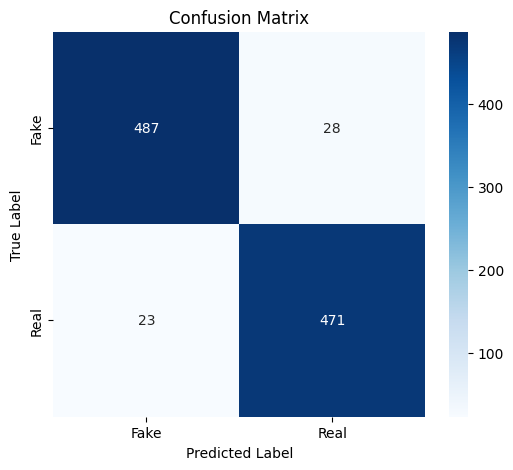


Classification Report:

              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95       515
        Real       0.94      0.95      0.95       494

    accuracy                           0.95      1009
   macro avg       0.95      0.95      0.95      1009
weighted avg       0.95      0.95      0.95      1009



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Model evaluation mode
model.eval()

all_preds = []
all_labels = []

# Turn off gradients for evaluation
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Fake", "Real"]))


In [27]:
# now saving the model 
# Save trained model and tokenizer
model_path = "saved_model_distilbert_multilingual_fake_news"

Tokenizer.save_pretrained(model_path)
model.save_pretrained(model_path)

print("✅ Model and tokenizer saved successfully!")


✅ Model and tokenizer saved successfully!


In [29]:
model_path = "/kaggle/working/saved_model_distilbert_multilingual_fake_news"
model_path

'/kaggle/working/saved_model_distilbert_multilingual_fake_news'

In [30]:
!zip -r saved_model_distilbert_multilingual_fake_news.zip \
       /kaggle/working/saved_model_distilbert_multilingual_fake_news


  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/ (stored 0%)
  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/config.json (deflated 49%)
  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/tokenizer_config.json (deflated 75%)
  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/tokenizer.json

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 67%)
  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/model.safetensors (deflated 7%)
  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/vocab.txt (deflated 45%)
  adding: kaggle/working/saved_model_distilbert_multilingual_fake_news/special_tokens_map.json (deflated 42%)


/kaggle/working/saved_model_distilbert_multilingual_fake_news.zip

In [ ]:
"""""
import optuna
import torch
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification

# Define Objective Function for Optuna
def objective(trial):
    # Load Pre-trained Model (Fine-tuning Required)
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-multilingual-cased", 
        num_labels=2
    )

    # Hyperparameter Search Space
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Training Arguments
    training_args = TrainingArguments(
        output_dir="./results",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=3,
        weight_decay=weight_decay,
        eval_strategy="epoch",  # ✅ Corrected (Previously 'eval_strategy')
        save_strategy="epoch",
        logging_dir="./logs",
        logging_steps=100,
        run_name="bert-finetuning-run"  # ✅ WandB Warning Fix
    )

    # Trainer Initialization
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,  # ✅ Using preprocessed dataset
        eval_dataset=val_dataset,
    )

    # Train the Model
    trainer.train()
    
    # Evaluate Performance
    eval_result = trainer.evaluate()
    
    return eval_result["eval_loss"]  # Minimizing Loss

# Optuna Study Initialization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)  # Running 10 Trials

# Print Best Hyperparameters
print("Best Hyperparameters:", study.best_params)
""""

In [ ]:
!nvidia-smi